In [1]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)  

In [2]:
# ===========================================
# ABG Motors Capstone Project
# Author: Khushi
# ===========================================

# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [3]:
# Load datasets

jpn = pd.read_excel("JPN Data.xlsx")
ind = pd.read_excel("IN_Data.xlsx")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [4]:
# First 5 rows of Japanese dataset

jpn.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR,PURCHASE
0,00001Q15YJ,50,M,445344.000000,439,0
1,00003I71CQ,35,M,107634.000000,283,0
2,00003N47FS,59,F,502786.666667,390,1
3,00005H41DE,43,M,585664.000000,475,0
4,00007E17UM,39,F,705722.666667,497,1


## Data Exploration

In [5]:
print("Japanese Dataset Shape:", jpn.shape)
print("Indian Dataset Shape:", ind.shape)

Japanese Dataset Shape: (40000, 6)
Indian Dataset Shape: (70000, 5)


### Dataset Information

In [6]:
# Information about Japanese dataset
jpn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ID          40000 non-null  object 
 1   CURR_AGE    40000 non-null  int64  
 2   GENDER      40000 non-null  object 
 3   ANN_INCOME  40000 non-null  float64
 4   AGE_CAR     40000 non-null  int64  
 5   PURCHASE    40000 non-null  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 1.8+ MB


In [7]:
# Information about Indian dataset
ind.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   ID          70000 non-null  object        
 1   CURR_AGE    70000 non-null  int64         
 2   GENDER      70000 non-null  object        
 3   ANN_INCOME  70000 non-null  int64         
 4   DT_MAINT    70000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 2.7+ MB


### Statistical Summary

In [8]:
jpn.describe()

,CURR_AGE,ANN_INCOME,AGE_CAR,PURCHASE
count,40000.00000,40000.000000,40000.000000,40000.000000
mean,44.99745,359398.878050,359.080250,0.575775
std,11.82008,175109.262950,203.063724,0.494231
min,25.00000,70089.000000,1.000000,0.000000
25%,35.00000,219766.000000,235.000000,0.000000
50%,45.00000,337656.833333,331.000000,1.000000
75%,55.00000,464261.000000,444.000000,1.000000
max,65.00000,799970.666667,1020.000000,1.000000


### Missing Values

In [9]:
jpn.isnull().sum()

ID            0
CURR_AGE      0
GENDER        0
ANN_INCOME    0
AGE_CAR       0
PURCHASE      0
dtype: int64

In [10]:
ind.isnull().sum()

ID            0
CURR_AGE      0
GENDER        0
ANN_INCOME    0
DT_MAINT      0
dtype: int64

### Duplicate Records

In [11]:
print("Japanese Dataset Duplicates:", jpn.duplicated().sum())
print("Indian Dataset Duplicates:", ind.duplicated().sum())

Japanese Dataset Duplicates: 0
Indian Dataset Duplicates: 0


## Data Cleaning & Feature Engineering

In [12]:
# Function to convert AGE_CAR into segments

def age_segment(days):
    if days < 200:
        return 1
    elif days <= 360:
        return 2
    elif days <= 500:
        return 3
    else:
        return 4

In [13]:
jpn["AGE_CAR_SEGMENT"] = jpn["AGE_CAR"].apply(age_segment)

In [14]:
jpn.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR,PURCHASE,AGE_CAR_SEGMENT
0,00001Q15YJ,50,M,445344.000000,439,0,3
1,00003I71CQ,35,M,107634.000000,283,0,2
2,00003N47FS,59,F,502786.666667,390,1,3
3,00005H41DE,43,M,585664.000000,475,0,3
4,00007E17UM,39,F,705722.666667,497,1,3


In [15]:
jpn["AGE_CAR_SEGMENT"].value_counts().sort_index()

AGE_CAR_SEGMENT
1     6459
2    16545
3    11697
4     5299
Name: count, dtype: int64

### Preparing Indian Dataset

In [16]:
analysis_date = pd.to_datetime("2019-07-01")

ind["AGE_CAR"] = (analysis_date - ind["DT_MAINT"]).dt.days

In [17]:
ind["AGE_CAR_SEGMENT"] = ind["AGE_CAR"].apply(age_segment)

In [18]:
ind.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,DT_MAINT,AGE_CAR,AGE_CAR_SEGMENT
0,20710B05XL,54,M,1425390,2018-04-20,437,3
1,89602T51HX,47,M,1678954,2018-06-08,388,3
2,70190Z52IP,60,M,931624,2017-07-31,700,4
3,25623V15MU,55,F,1106320,2017-07-31,700,4
4,36230I68CE,32,F,748465,2019-01-27,155,1


In [19]:
ind["AGE_CAR_SEGMENT"].value_counts().sort_index()

AGE_CAR_SEGMENT
1    18496
2    18994
3    18691
4    13819
Name: count, dtype: int64

## Preparing Data for Machine Learning

In [20]:
# Convert Gender into numeric values

jpn["GENDER"] = jpn["GENDER"].map({"M":1, "F":0})
ind["GENDER"] = ind["GENDER"].map({"M":1, "F":0})

In [21]:
# Drop unnecessary columns

jpn = jpn.drop(columns=["ID", "AGE_CAR"])
ind = ind.drop(columns=["ID", "DT_MAINT", "AGE_CAR"])

In [22]:
jpn.head()

,CURR_AGE,GENDER,ANN_INCOME,PURCHASE,AGE_CAR_SEGMENT
0,50,1,445344.000000,0,3
1,35,1,107634.000000,0,2
2,59,0,502786.666667,1,3
3,43,1,585664.000000,0,3
4,39,0,705722.666667,1,3


In [23]:
ind.head()

,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR_SEGMENT
0,54,1,1425390,3
1,47,1,1678954,3
2,60,1,931624,4
3,55,0,1106320,4
4,32,0,748465,1


In [24]:
# Features and Target

X = jpn.drop("PURCHASE", axis=1)
y = jpn["PURCHASE"]

In [25]:
print(X.shape)
print(y.shape)

(40000, 4)
(40000,)


## Train-Test Split

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [27]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(32000, 4)
(8000, 4)
(32000,)
(8000,)


## Build the Decision Tree Classifier

In [28]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Predict on Test Data

In [29]:
y_pred = dt_model.predict(X_test)

## Model Evaluation

In [30]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.62925


In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1890 1459]
 [1507 3144]]


In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.56      0.56      3349
           1       0.68      0.68      0.68      4651

    accuracy                           0.63      8000
   macro avg       0.62      0.62      0.62      8000
weighted avg       0.63      0.63      0.63      8000



## Decision Tree Visualization

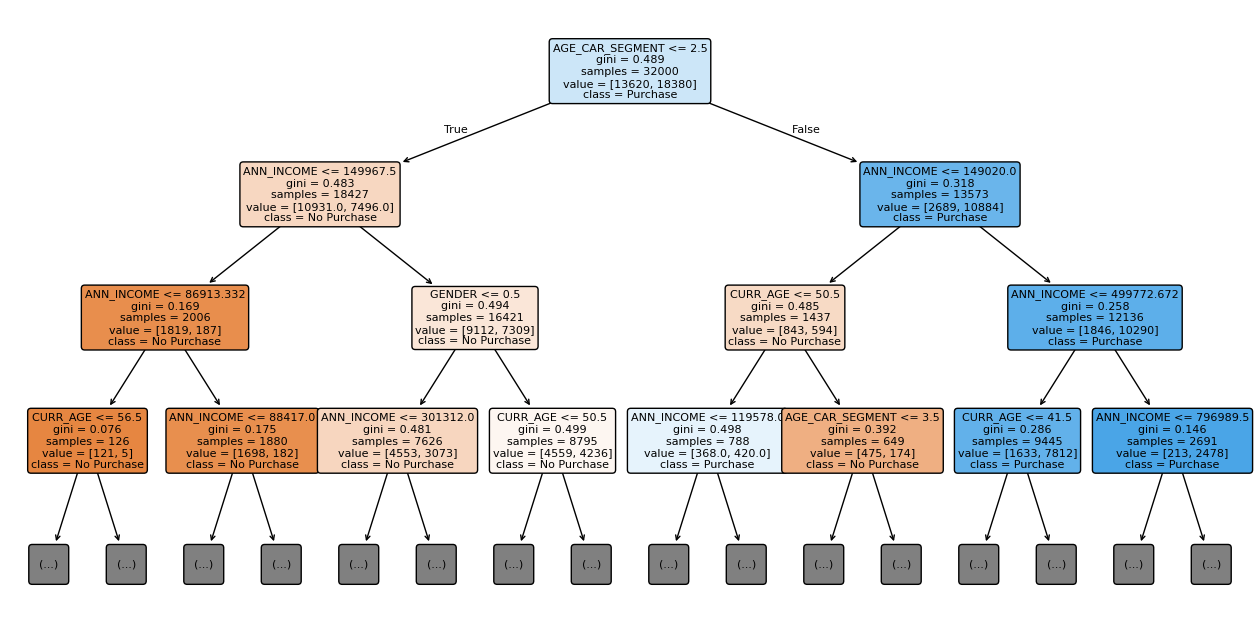

In [33]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(16,8))

plot_tree(
    dt_model,
    max_depth=3,
    feature_names=X.columns,
    class_names=["No Purchase","Purchase"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

## Feature Importance

In [34]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt_model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

           Feature  Importance
2       ANN_INCOME    0.638096
0         CURR_AGE    0.181299
3  AGE_CAR_SEGMENT    0.171351
1           GENDER    0.009254


In [35]:
print(X.columns.tolist())

['CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR_SEGMENT']


## Load the Indian Dataset

In [36]:
import pandas as pd

india_df = pd.read_excel(
    "IN_Data.xlsx",
    sheet_name="IN_Mobiles",
    engine="openpyxl"
)

india_df.head()
india_df.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,DT_MAINT
0,20710B05XL,54,M,1425390,2018-04-20
1,89602T51HX,47,M,1678954,2018-06-08
2,70190Z52IP,60,M,931624,2017-07-31
3,25623V15MU,55,F,1106320,2017-07-31
4,36230I68CE,32,F,748465,2019-01-27


In [37]:
india_df.columns

Index(['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'DT_MAINT'], dtype='object')

## Create the AGE_CAR Feature

The AGE_CAR feature is calculated using the analysis date of **1 July 2019**, as specified in the project assumptions.

In [38]:
# Convert DT_MAINT to datetime
india_df["DT_MAINT"] = pd.to_datetime(india_df["DT_MAINT"])

# Analysis date
analysis_date = pd.to_datetime("2019-07-01")

# Calculate AGE_CAR
india_df["AGE_CAR"] = (analysis_date - india_df["DT_MAINT"]).dt.days

india_df[["DT_MAINT", "AGE_CAR"]].head()

,DT_MAINT,AGE_CAR
0,2018-04-20,437
1,2018-06-08,388
2,2017-07-31,700
3,2017-07-31,700
4,2019-01-27,155


## Create AGE_CAR_SEGMENT

The AGE_CAR variable is divided into four categories according to the project assumptions.

In [39]:
india_df["AGE_CAR_SEGMENT"] = pd.cut(
    india_df["AGE_CAR"],
    bins=[-float("inf"), 200, 360, 500, float("inf")],
    labels=[1, 2, 3, 4]
)

india_df["AGE_CAR_SEGMENT"] = india_df["AGE_CAR_SEGMENT"].astype(int)

india_df[["AGE_CAR", "AGE_CAR_SEGMENT"]].head()

,AGE_CAR,AGE_CAR_SEGMENT
0,437,3
1,388,3
2,700,4
3,700,4
4,155,1


## Encode the Gender Variable

In [40]:
india_df["GENDER"] = india_df["GENDER"].map({"M": 1, "F": 0})

In [41]:
india_df.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,DT_MAINT,AGE_CAR,AGE_CAR_SEGMENT
0,20710B05XL,54,1,1425390,2018-04-20,437,3
1,89602T51HX,47,1,1678954,2018-06-08,388,3
2,70190Z52IP,60,1,931624,2017-07-31,700,4
3,25623V15MU,55,0,1106320,2017-07-31,700,4
4,36230I68CE,32,0,748465,2019-01-27,155,1


# Select Features for Prediction

Select the same predictor variables that were used while training the Decision Tree model on the Japanese dataset.

In [42]:
X_india = india_df[['CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR_SEGMENT']]

X_india.head()

,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR_SEGMENT
0,54,1,1425390,3
1,47,1,1678954,3
2,60,1,931624,4
3,55,0,1106320,4
4,32,0,748465,1


# Predict Purchase Decisions

Use the trained Decision Tree model developed from the Japanese dataset to predict purchase decisions for the Indian dataset.

In [43]:
india_predictions = dt_model.predict(X_india)

# Add Predictions to the Dataset

Store the predicted purchase values in a new column named **Predicted_Purchase**.

In [44]:
india_df['Predicted_Purchase'] = india_predictions

india_df.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,DT_MAINT,AGE_CAR,AGE_CAR_SEGMENT,Predicted_Purchase
0,20710B05XL,54,1,1425390,2018-04-20,437,3,1
1,89602T51HX,47,1,1678954,2018-06-08,388,3,1
2,70190Z52IP,60,1,931624,2017-07-31,700,4,1
3,25623V15MU,55,0,1106320,2017-07-31,700,4,1
4,36230I68CE,32,0,748465,2019-01-27,155,1,0


# Count Potential Customers

Count the number of customers predicted to purchase a new car in the Indian market.

In [45]:
potential_customers = india_df['Predicted_Purchase'].sum()

print("Potential Customers:", potential_customers)

Potential Customers: 48958


In [46]:
india_df['Predicted_Purchase'].value_counts()

Predicted_Purchase
1    48958
0    21042
Name: count, dtype: int64

# Export Predictions

Export the final dataset with the predicted purchase values to an Excel file.

In [47]:
india_df.to_excel("Indian_Predictions.xlsx", index=False)

print("Indian_Predictions.xlsx has been created successfully.")

Indian_Predictions.xlsx has been created successfully.


# Business Conclusion

The Decision Tree classification model was trained using the Japanese dataset and then applied to the Indian dataset to predict whether customers are likely to purchase a new car. The same preprocessing steps, including gender encoding and age car segmentation, were applied to both datasets to maintain consistency. The predicted customers represent potential buyers for ABG Motors in the Indian market. These predictions can help the company target potential customers more effectively and support its decision regarding expansion into India.

In [48]:
india_df.to_excel("Indian_Predictions.xlsx", index=False)